## Titanic Survival Prediction
## Objective:- Predict whether a passenger survived the titanic disaster using machine learning
## Machine Learning Problem:- Classification
## Model :- Logistic Regression

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/04_titanic.csv")
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,2,Passenger 1,male,19.4,1,0,19.88,Q,0
1,2,3,Passenger 2,male,28.4,1,2,41.51,C,0
2,3,2,Passenger 3,male,1.0,3,1,54.77,S,0
3,4,3,Passenger 4,female,14.4,2,2,29.91,S,1
4,5,3,Passenger 5,male,5.1,1,0,41.67,S,0
...,...,...,...,...,...,...,...,...,...,...
895,896,1,Passenger 896,male,32.2,3,1,14.83,S,0
896,897,1,Passenger 897,female,15.8,0,2,15.56,Q,1
897,898,1,Passenger 898,male,35.1,0,2,42.90,S,1
898,899,1,Passenger 899,male,20.4,1,1,21.04,S,0


In [3]:
df.shape

(900, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  900 non-null    int64  
 1   Pclass       900 non-null    int64  
 2   Name         900 non-null    object 
 3   Sex          900 non-null    object 
 4   Age          900 non-null    float64
 5   SibSp        900 non-null    int64  
 6   Parch        900 non-null    int64  
 7   Fare         900 non-null    float64
 8   Embarked     900 non-null    object 
 9   Survived     900 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0


In [11]:
X = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']].copy()
y = df['Survived']

In [12]:
X['Age'] = X['Age'].fillna(X['Age'].mean())
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])
print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [13]:
X = pd.get_dummies(X,columns=['Sex','Embarked'],drop_first=True)
print("PreProcessing Data:")
print(X.head())

PreProcessing Data:
   Pclass   Age  SibSp  Parch   Fare  Sex_male  Embarked_Q  Embarked_S
0       2  19.4      1      0  19.88      True        True       False
1       3  28.4      1      2  41.51      True       False       False
2       2   1.0      3      1  54.77      True       False        True
3       3  14.4      2      2  29.91     False       False        True
4       3   5.1      1      0  41.67      True       False        True


In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Acuuracy Score:")
print(accuracy_score(y_test,y_pred))

Acuuracy Score:
0.7388888888888889


In [18]:
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.84       129
           1       0.58      0.27      0.37        51

    accuracy                           0.74       180
   macro avg       0.67      0.60      0.60       180
weighted avg       0.71      0.74      0.70       180



In [19]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Confusion Matrix:
[[119  10]
 [ 37  14]]


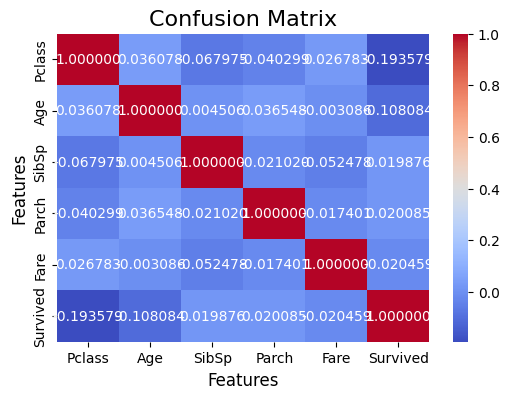

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt="2f", cmap="coolwarm")
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Confusion Matrix", fontsize=16)
plt.show()